# PART 1

In [2]:
# TODO: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch
import os

# TODO: define paths
FEATURES_PATH = "/shared/NX-414/extracted_features/"
DATA_PATH = "/shared/NX-414/data/"

TVSD = "tvsd.h5" #macaque electrophysiology from 2 monkeys, with 22,248 train and 100 test stimuli, covering V1, V4, and IT.
THINGS_EEG2 = "things_eeg2.h5" #human EEG from 10 subjects, with 16,540 train and 200 test stimuli, with region 
                                # groupings such as occipital, parietal, temporal, frontal, central, occipital_parietal, and whole_brain.
NSD = "nsd_func1pt8mm_individualROIs.h5"#human fMRI from 8 subjects, with roughly 9,000 train and 1,000 test stimuli per subject, across multiple visual ROIs.

THINGS_EEG2_TEST = "things_eeg2-test_reps.h5" #EEG test responses with repetitions and without averaging.
NSD_fsaverage = "nsd-subj01-ncsnr-{lh,rh}.mgh"  #Surface-based NSD reliability values for subj-01 on fsaverage.


Model_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"  #ResNet-152
Model_B = "Qwen3-VL-2B-Instruct"  #vision-language transformer

Neural response shapes
- TVSD: (n_stimuli, n_units)
- EEG2: (n_stimuli, n_channels, n_timepoints)
- NSD: (n_stimuli, n_voxels)

In [3]:
# TODO: inspect dataset structure
from pathlib import Path

print("In : " + FEATURES_PATH)
for item in Path(FEATURES_PATH).rglob("*"):
    print(item)

print("In : " + DATA_PATH)
for item in Path(DATA_PATH).rglob("*"):
    print(item)



In : /shared/NX-414/extracted_features/
/shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct
/shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5
/shared/NX-414/extracted_features/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/nsd_stimuli.h5
/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/nsd_stimuli.h5
/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/things_stimuli.h5
In : /shared/NX-414/data/
/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
/shared/NX-414/data/things_eeg2.h5
/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh
/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5
/shared/NX-414/data/things_eeg2-test_reps.h5
/shared/NX-414/data/tvsd.h5


# Summary

In : **/shared/NX-414/extracted_features/**

tvsd.h5
noise_ceilings monkeyF and monkeyN, IT, V1 and V4
test
train

- adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
- Qwen3-VL-2B-Instruct
- adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5
- adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/nsd_stimuli.h5
- Qwen3-VL-2B-Instruct/nsd_stimuli.h5
- Qwen3-VL-2B-Instruct/things_stimuli.h5

In : **/shared/NX-414/data/**

- /shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
- /shared/NX-414/data/things_eeg2.h5
- /shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh
- /shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5
- /shared/NX-414/data/things_eeg2-test_reps.h5
- /shared/NX-414/data/tvsd.h5

EEG
- /shared/NX-414/data/things_eeg2.h5
  - stimuli: train=16540, test=200
  - subjects: 10
  - regions per subject: 7
  - data shape: (stimuli, channels, time) = (*, 14, 80)
- /shared/NX-414/data/things_eeg2-test_reps.h5
  - stimuli: train=0, test=200
  - subjects: 10
  - regions per subject: 7
  - data shape: (stimuli, channels, time) = (*, 14, 80)

TVSD
- /shared/NX-414/data/tvsd.h5
  - stimuli: train=22248, test=100
  - subjects: 2
  - regions per subject: 3

In [10]:
# nx414_utility.inspect_files("/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5")          #useful to print everything

nx414_utility.summarize_tvsd()
nx414_utility.summarize_eeg("/shared/NX-414/data/things_eeg2.h5")


📦 TVSD Summary: /shared/NX-414/data/tvsd.h5
  Train stimuli: 22248
  Test stimuli:  100

  Neural data (per monkey × area):
    monkeyF  | IT | units:  241 | train: 22248 | test: 100
    monkeyF  | V1 | units:  462 | train: 22248 | test: 100
    monkeyF  | V4 | units:  139 | train: 22248 | test: 100
    monkeyN  | IT | units:  178 | train: 22248 | test: 100
    monkeyN  | V1 | units:  437 | train: 22248 | test: 100
    monkeyN  | V4 | units:  247 | train: 22248 | test: 100

📦 THINGS-EEG2 Summary: /shared/NX-414/data/things_eeg2.h5
  Train stimuli: 16540
  Test stimuli:  200

  Neural data (per subject × region):
    sub-01  | central              | channels: 14 | time: 80 | train: 16540 | test: 200
    sub-01  | frontal              | channels: 21 | time: 80 | train: 16540 | test: 200
    sub-01  | occipital            | channels:  3 | time: 80 | train: 16540 | test: 200
    sub-01  | occipital_parietal   | channels: 17 | time: 80 | train: 16540 | test: 200
    sub-01  | parietal     

## Matching features to neural responses



In [1]:
import utility_metadata

## Load data metadata

In [5]:
meta = utility_metadata.load_metadata("/shared/NX-414/data/things_eeg2.h5")

print(meta.keys())
print(meta["train_ids"].shape)
print(meta["subjects_or_monkeys"])

dict_keys(['train_ids', 'test_ids', 'subjects_or_monkeys', 'regions'])
(16540,)
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']


In [6]:
meta = utility_metadata.load_metadata("/shared/NX-414/data/things_eeg2-test_reps.h5")

print(meta.keys())
print(meta["test_ids"].shape)
print(meta["subjects_or_monkeys"])

dict_keys(['test_ids', 'subjects_or_monkeys', 'regions'])
(200,)
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']


In [7]:
meta = utility_metadata.load_metadata("/shared/NX-414/data/tvsd.h5")

print(meta.keys())
print(meta["train_ids"].shape)
print(meta["subjects_or_monkeys"])

dict_keys(['train_ids', 'test_ids', 'subjects_or_monkeys', 'regions'])
(22248,)
['monkeyF', 'monkeyN']


## Load features metadata

In [16]:
feat_meta = utility_metadata.load_feature_metadata(
    "/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/things_stimuli.h5"
)

print(feat_meta["n_stimuli"])
print(feat_meta["layers"][:3])

26107
['language_model-layers-11', 'language_model-layers-16', 'language_model-layers-3']


In [20]:
neural_ids = meta["train_ids"]
feature_ids = feat_meta["ids"]

# sanity check
assert len(neural_ids) <= len(feature_ids)
set(neural_ids).issubset(set(feature_ids))

False

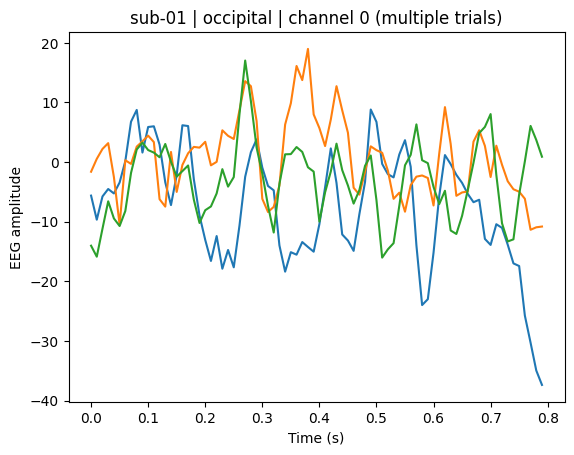

In [40]:
def plot_multiple_trials(
    path="/shared/NX-414/data/things_eeg2.h5",
    subject="sub-01",
    region="occipital",
    split="train",
    channel_idx=0,
    n_trials=3
):

    with h5py.File(path, "r") as f:
        data = f[f"{split}/neural_data/{subject}/{region}"]

        n_time = data.shape[2]
        time = np.arange(n_time) / 100

        plt.figure()

        for i in range(n_trials):
            signal = data[i, channel_idx, :]
            plt.plot(time, signal)

    plt.xlabel("Time (s)")
    plt.ylabel("EEG amplitude")
    plt.title(f"{subject} | {region} | channel {channel_idx} (multiple trials)")
    plt.show()

plot_multiple_trials()

In [ ]:
def plot_eeg_heatmap(
    path="/shared/NX-414/data/things_eeg2.h5",
    subject="sub-01",
    region="frontal",
    split="train"
):

    with h5py.File(path, "r") as f:
        data = f[f"{split}/neural_data/{subject}/{region}"][:]
        # shape: (stimuli, channels, time)

    # Average across stimuli → necessary to see structure
    signal = data.mean(axis=0)  # (channels, time)

    plt.figure()
    plt.imshow(signal, aspect='auto')
    plt.colorbar(label="EEG amplitude")

    plt.xlabel("Time (samples)")
    plt.ylabel("Channels")
    plt.title(f"EEG Heatmap | {subject} | {region}")

    plt.show()

plot_eeg_heatmap()

(21, 80)


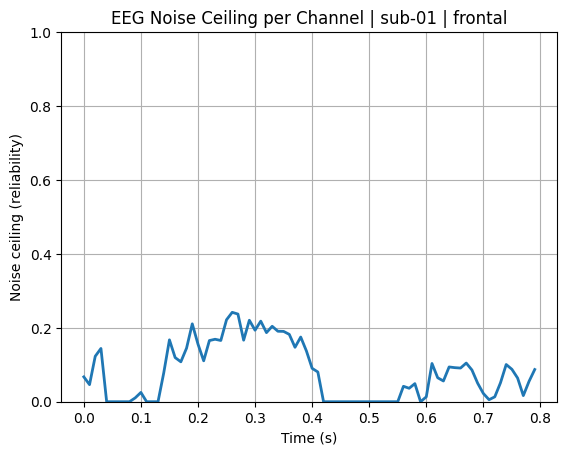

In [63]:
def plot_provided_eeg_noise_ceiling(
    path="/shared/NX-414/data/things_eeg2.h5",
    subject="sub-01",
    region="frontal",
    max_channels = 1
):
    with h5py.File(path, "r") as f:
        nc = f[f"noise_ceilings/{subject}/{region}"][:]

    nc = nc / 100.0
    print(nc.shape)

    n_channels, n_time = nc.shape
    time = np.arange(n_time) / 100  # 100 Hz → 0–0.8s

    plt.figure()

    for ch in range(min(n_channels, max_channels)):
        plt.plot(time, nc[ch], linewidth=2)

    plt.xlabel("Time (s)")
    plt.ylabel("Noise ceiling (reliability)")
    plt.title(f"EEG Noise Ceiling per Channel | {subject} | {region}")
    plt.ylim(0, 1)
    plt.grid(True)

    plt.show()
plot_provided_eeg_noise_ceiling()

## Noise Ceilings

In [55]:
import noise_ceilings

In [56]:
path = "/shared/NX-414/data/things_eeg2-test_reps.h5"
subject = "sub-01"
region = "frontal"

with h5py.File(path, "r") as f:
    data = f[f"test/neural_data/{subject}/{region}"][:]

# (stimuli, channels, time, reps)
responses = np.transpose(data, (1, 2, 0, 3))
print(responses.shape)

nc = noise_ceilings.compute_ceiling_variancebased(responses)

nc = nc / 100.0

print("Noise ceiling shape:", nc.shape)

(21, 80, 200, 80)
Noise ceiling shape: (21, 80)


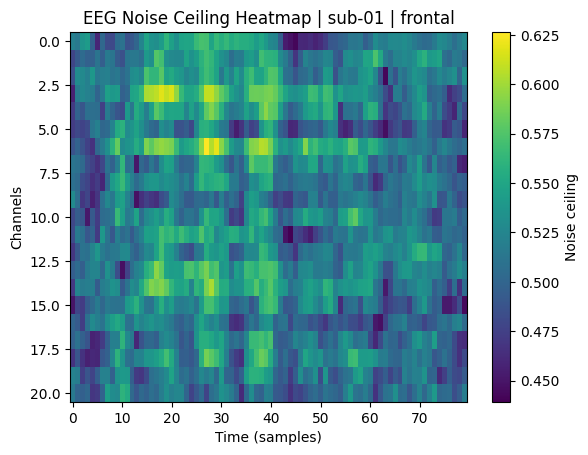

In [57]:
def plot_eeg_noise_ceiling_heatmap(nc, subject, region):

    # If needed: convert percent → [0,1]
    nc = nc / 100.0 if nc.max() > 1 else nc

    plt.figure()
    plt.imshow(nc, aspect="auto")
    plt.colorbar(label="Noise ceiling")

    plt.xlabel("Time (samples)")
    plt.ylabel("Channels")
    plt.title(f"EEG Noise Ceiling Heatmap | {subject} | {region}")

    plt.show()
    
plot_eeg_noise_ceiling_heatmap(nc, subject, region)

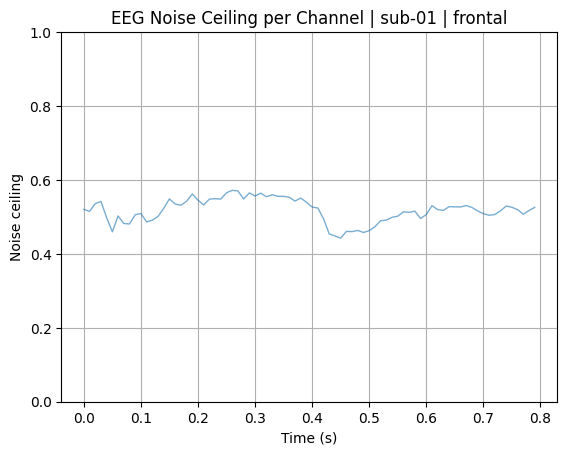

In [59]:
def plot_eeg_noise_ceiling_channels(nc, subject="sub-01", region="frontal", max_channels = 1):

    # ensure [0,1]
    nc = nc / 100.0 if nc.max() > 1 else nc

    n_channels, n_time = nc.shape
    time = np.arange(n_time) / 100  # 100 Hz

    plt.figure()

    for ch in range(min(n_channels, max_channels)):
        plt.plot(time, nc[ch], alpha=0.6, linewidth=1)

    plt.xlabel("Time (s)")
    plt.ylabel("Noise ceiling")
    plt.title(f"EEG Noise Ceiling per Channel | {subject} | {region}")
    plt.ylim(0, 1)
    plt.grid(True)

    plt.show()

plot_eeg_noise_ceiling_channels(nc)

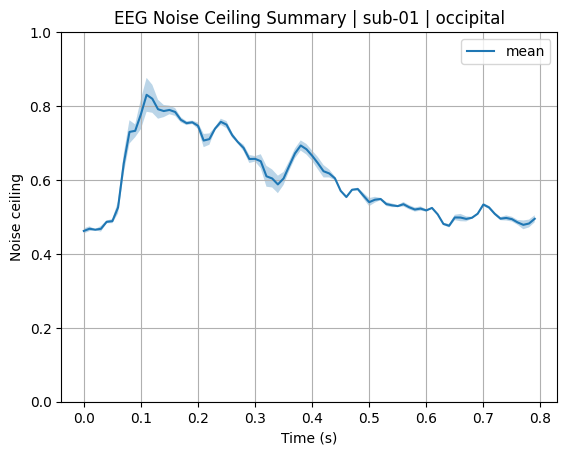

In [27]:
def plot_eeg_noise_ceiling_summary(nc, subject="sub-01", region="occipital"):
    import numpy as np
    import matplotlib.pyplot as plt

    nc = nc / 100.0 if nc.max() > 1 else nc

    mean_nc = nc.mean(axis=0)  # average over channels
    std_nc = nc.std(axis=0)

    time = np.arange(mean_nc.shape[0]) / 100  # 100 Hz

    plt.figure()
    plt.plot(time, mean_nc, label="mean")
    plt.fill_between(time, mean_nc - std_nc, mean_nc + std_nc, alpha=0.3)

    plt.xlabel("Time (s)")
    plt.ylabel("Noise ceiling")
    plt.title(f"EEG Noise Ceiling Summary | {subject} | {region}")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid()
    plt.show()

plot_eeg_noise_ceiling_summary(nc)

## compute_ceiling_splithalf

In [1]:
import noise_ceilings
import h5py
import numpy as np

In [4]:
def compute_subject_region_reliability(
    path: str,
    subject: str,
    region: str,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = False,
    equalize_halves: bool = True,
    clip_folds: bool = False,
) -> np.ndarray:
    """
    Load EEG data from HDF5 and compute split-half reliability.

    Returns
    -------
    np.ndarray
        Shape (channels, timepoints)
    """

    key = f"test/neural_data/{subject}/{region}"

    with h5py.File(path, "r") as f:
        data = f[key][...]  # (stimuli, channels, timepoints, reps)

    # --- sanity check ---
    if data.ndim != 4:
        raise ValueError(f"Unexpected shape: {data.shape}")

    # --- reorder to expected format ---
    # (stimuli, channels, timepoints, reps)
    # -> (channels, timepoints, stimuli, reps)
    data = np.transpose(data, (1, 2, 0, 3))

    # --- compute reliability ---
    reliability = noise_ceilings.compute_ceiling_splithalf(
        responses=data,
        folds=folds,
        seed=seed,
        spearman_brown=spearman_brown,
        equalize_halves=equalize_halves,
        clip_folds=clip_folds,
    )


    return reliability

In [6]:
path = "/shared/NX-414/data/things_eeg2-test_reps.h5"
subject = "sub-01"
region = "frontal"

rel = compute_subject_region_reliability(
    path=path,
    subject=subject,
    region=region
)


with h5py.File(path, "r") as f:
    data = f[f"test/neural_data/{subject}/{region}"][:]

# (stimuli, channels, time, reps)
responses = np.transpose(data, (1, 2, 0, 3))
print(responses.shape)

nc = noise_ceilings.compute_ceiling_variancebased(responses)

nc = nc / 100.0

print("Noise ceiling shape:", nc.shape)

print(rel.shape)  # (21, 80)

print("Split-half mean:", np.nanmean(rel))
print("Variance mean:", np.nanmean(nc))

(21, 80, 200, 80)
Noise ceiling shape: (21, 80)
(21, 80)
Split-half mean: 0.03262312252235314
Variance mean: 0.5199009991038588


(80,)


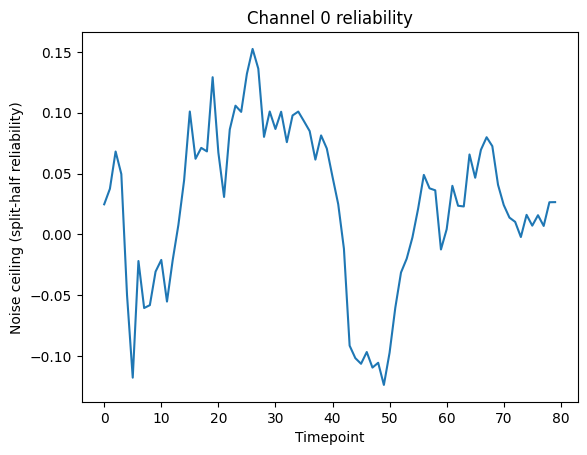

In [11]:
import matplotlib.pyplot as plt

channel_idx = 0  # pick your channel
channel_reliability = rel[channel_idx]  # shape: (timepoints,)

print(channel_reliability.shape)  # (80,)

plt.plot(channel_reliability)
plt.xlabel("Timepoint")
plt.ylabel("Noise ceiling (split-half reliability)")
plt.title(f"Channel {channel_idx} reliability")
plt.show()

In [13]:
import h5py
import numpy as np
import noise_ceilings

path_reps = "/shared/NX-414/data/things_eeg2-test_reps.h5"
path_avg  = "/shared/NX-414/data/things_eeg2.h5"

subjects = [f"sub-{i:02d}" for i in range(1, 11)]
regions = [
    "central", "frontal", "occipital",
    "occipital_parietal", "parietal",
    "temporal", "whole_brain"
]

results = []

with h5py.File(path_reps, "r") as f_reps, h5py.File(path_avg, "r") as f_avg:

    for sub in subjects:
        for region in regions:

            key = f"test/neural_data/{sub}/{region}"

            # --- load repetitions ---
            data = f_reps[key][...]  # (stimuli, channels, timepoints, reps)

            # reorder → (channels, timepoints, stimuli, reps)
            data = np.transpose(data, (1, 2, 0, 3))

            # --- compute estimators ---
            split_half = noise_ceilings.compute_ceiling_splithalf(data)
            variance   = noise_ceilings.compute_ceiling_variance(data)

            # --- load provided ceiling ---
            # looks like: noise_ceilings/sub-01/central: shape = (14, 80)
            provided = f_avg[f"noise_ceilings/{sub}/{region}"][...]

            # --- summarize ---
            res = {
                "subject": sub,
                "region": region,
                "split_half_mean": np.nanmean(split_half),
                "variance_mean": np.nanmean(variance),
                "provided_mean": np.nanmean(provided/100),
            }

            results.append(res)

            print(
                f"{sub} | {region:20s} | "
                f"split: {res['split_half_mean']:.4f} | "
                f"var: {res['variance_mean']:.4f} | "
                f"provided: {res['provided_mean']:.4f}"
            )

# ---------------------------
# Convert to array for analysis
# ---------------------------

import pandas as pd

df = pd.DataFrame(results)

print("\n=== Overall means ===")
print(df[["split_half_mean", "variance_mean", "provided_mean"]].mean())

print("\n=== By region ===")
print(df.groupby("region")[["split_half_mean", "variance_mean", "provided_mean"]].mean())

sub-01 | central              | split: 0.0529 | var: 0.0977 | provided: 0.1072
sub-01 | frontal              | split: 0.0520 | var: 0.0753 | provided: 0.0804
sub-01 | occipital            | split: 0.2696 | var: 0.2954 | provided: 0.2989
sub-01 | occipital_parietal   | split: 0.2000 | var: 0.2341 | provided: 0.2529
sub-01 | parietal             | split: 0.1851 | var: 0.2210 | provided: 0.2430
sub-01 | temporal             | split: 0.1962 | var: 0.2222 | provided: 0.2265
sub-01 | whole_brain          | split: 0.1043 | var: 0.1372 | provided: 0.1469
sub-02 | central              | split: 0.1455 | var: 0.1504 | provided: 0.1543
sub-02 | frontal              | split: 0.0805 | var: 0.0921 | provided: 0.0963
sub-02 | occipital            | split: 0.3270 | var: 0.3247 | provided: 0.3301
sub-02 | occipital_parietal   | split: 0.2850 | var: 0.2837 | provided: 0.2888
sub-02 | parietal             | split: 0.2760 | var: 0.2749 | provided: 0.2799
sub-02 | temporal             | split: 0.2283 | var:

In [14]:
from scipy.stats import ttest_rel

mse_split = []
mse_var = []

with h5py.File(path_reps, "r") as f_reps, h5py.File(path_avg, "r") as f_avg:

    for sub in subjects:

        sub_mse_split = []
        sub_mse_var = []

        for region in regions:
            print("Computing for " + sub+  " and region " + region)
                 

            key = f"test/neural_data/{sub}/{region}"

            data = f_reps[key][...]
            data = np.transpose(data, (1, 2, 0, 3))

            split_half = noise_ceilings.compute_ceiling_splithalf(data)
            variance   = noise_ceilings.compute_ceiling_variance(data)

            provided = f_avg[f"noise_ceilings/{sub}/{region}"][...] / 100

            # --- compute MSE per region ---
            mse_s = np.nanmean((split_half - provided) ** 2)
            mse_v = np.nanmean((variance   - provided) ** 2)

            sub_mse_split.append(mse_s)
            sub_mse_var.append(mse_v)

        # --- average across regions → ONE value per subject ---
        mse_split.append(np.mean(sub_mse_split))
        mse_var.append(np.mean(sub_mse_var))

In [15]:
mse_split = np.array(mse_split)
mse_var   = np.array(mse_var)

t_stat, p_val = ttest_rel(mse_split, mse_var)

print("\n=== Paired t-test (split vs variance) ===")
print(f"Mean MSE split-half: {mse_split.mean():.6f}")
print(f"Mean MSE variance:   {mse_var.mean():.6f}")
print(f"t = {t_stat:.4f}, p = {p_val:.6f}")


=== Paired t-test (split vs variance) ===
Mean MSE split-half: 0.003591
Mean MSE variance:   0.000892
t = 5.9697, p = 0.000210


# PART 3

Combining multiple layers — instead of selecting the single best layer, concatenate or average features from several layers and see if that predicts neural responses better
- extension of what we already did in part 2
- easy to compare fairly against the single-best-layer baseline

Hypothesis: 
"Different layers encode different levels of visual abstraction. Combining them should give the encoding model access to both low-level and high-level features simultaneously, improving predictions."

Questions:
- does combining the top-k layers beat the single best?

Why PCA:
If we have 10 layers × 30,000 features = 300,000 features. Ridge regression will struggle (memory, compute, overfitting). We need to reduce dimensionality first -> PCA

For now, we are testing with 1 layers, 2, 3, ... based on top-k layers (use only the k best-performing layers from Section 2)

We can play on:
- How to combine the layers:
  - concatenation : all layers contribute equally before Ridge learns weights
  - weighted average: more compact but loses per-layer spatial structure
  - separate Ridge per layer, then average predictions: acts like an ensemble, each layer votes independently
- In wish orders are the layers (best->worst, shallow -> deep
  - The orders can depends of the ROI ( V1 likely prefers early layers, V4 likely prefers mid layers, IT likely prefers deep layers)

Infos: 

k=1 baseline is always the true single-best-layer for that ROI

In [4]:
import h5py
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────────
FEAT_DIR   = '/shared/NX-414/extracted_features'
RESNET_PATH = f'{FEAT_DIR}/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/things_stimuli.h5'
QWEN_PATH   = f'{FEAT_DIR}/Qwen3-VL-2B-Instruct/things_stimuli.h5'
TVSD_PATH   = '/shared/NX-414/data/tvsd.h5'

# ── Layer ordering (shallow → deep) ───────────────────────────────────────────
RESNET_LAYERS = [
    'features/layer1-0',
    'features/layer2-0',
    'features/layer3-0',
    'features/layer3-5',
    'features/layer3-10',
    'features/layer3-15',
    'features/layer3-20',
    'features/layer3-25',
    'features/layer3-30',
    'features/layer4-1',
]

QWEN_LAYERS = [
    'features/visual-blocks-2',
    'features/visual-blocks-6',
    'features/visual-blocks-10',
    'features/visual-blocks-14',
    'features/visual-blocks-18',
    'features/visual-blocks-22',
    'features/language_model-layers-3',
    'features/language_model-layers-8',
    'features/language_model-layers-11',
    'features/language_model-layers-16',
]

MONKEYS = ['monkeyF', 'monkeyN']
ROIS    = ['V1', 'V4', 'IT']

def load_tvsd(tvsd_path):
    """
    Returns
    -------
    neural_train : dict  (monkey, roi) -> (n_train, n_units)
    neural_test  : dict  (monkey, roi) -> (n_test,  n_units)
    train_ids    : np.ndarray (22248,) byte strings
    test_ids     : np.ndarray (100,)   byte strings
    noise_ceil   : dict  (monkey, roi) -> (n_units,)  in [0, 1]
    """
    neural_train = {}
    neural_test  = {}
    noise_ceil   = {}

    with h5py.File(tvsd_path, 'r') as f:
        train_ids = f['train/stimulus_ids'][:]
        test_ids  = f['test/stimulus_ids'][:]

        for monkey in MONKEYS:
            for roi in ROIS:
                key = (monkey, roi)
                neural_train[key] = f[f'train/neural_data/{monkey}/{roi}'][:]
                neural_test[key]  = f[f'test/neural_data/{monkey}/{roi}'][:]
                # divide by 100 to get [0, 1]
                noise_ceil[key]   = f[f'noise_ceilings/{monkey}/{roi}'][:] / 100.0

    return neural_train, neural_test, train_ids, test_ids, noise_ceil


neural_train, neural_test, train_ids, test_ids, noise_ceil = load_tvsd(TVSD_PATH)

print("Train IDs:", train_ids.shape, train_ids.dtype, "| example:", train_ids[0])
print("Test  IDs:", test_ids.shape,  test_ids.dtype,  "| example:", test_ids[0])
print()
for monkey in MONKEYS:
    for roi in ROIS:
        key = (monkey, roi)
        print(f"{monkey} {roi:<3} | "
              f"train={neural_train[key].shape} "
              f"test={neural_test[key].shape}  "
              f"nc_mean={noise_ceil[key].mean():.3f}")

Train IDs: (22248,) object | example: b'aardvark/aardvark_01b.jpg'
Test  IDs: (100,) object | example: b'alligator/alligator_14n.jpg'

monkeyF V1  | train=(22248, 462) test=(100, 462)  nc_mean=0.943
monkeyF V4  | train=(22248, 139) test=(100, 139)  nc_mean=0.962
monkeyF IT  | train=(22248, 241) test=(100, 241)  nc_mean=0.930
monkeyN V1  | train=(22248, 437) test=(100, 437)  nc_mean=0.973
monkeyN V4  | train=(22248, 247) test=(100, 247)  nc_mean=0.957
monkeyN IT  | train=(22248, 178) test=(100, 178)  nc_mean=0.955


In [5]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def load_features_for_ids(feat_path, layer_name, target_ids):
    """Load feature rows matching target_ids from an h5 file."""
    with h5py.File(feat_path, 'r') as f:
        feat_ids = f['ids'][:]
        id_to_idx = {id_: i for i, id_ in enumerate(feat_ids)}
        feat_idx  = np.array([id_to_idx[x] for x in target_ids])
        # sort for efficient HDF5 read, then restore order
        sort_order    = np.argsort(feat_idx)
        restore_order = np.argsort(sort_order)
        feats = f[layer_name][feat_idx[sort_order]].astype(np.float32)
    return feats[restore_order]


def pearsonr_matrix(Y_pred, Y_true):
    """Pearson r for each column (unit). Returns (n_units,)."""
    n_units = Y_true.shape[1]
    r = np.array([pearsonr(Y_pred[:, i], Y_true[:, i])[0] for i in range(n_units)])
    return r


def ev_matrix(Y_pred, Y_true):
    """Explained variance per unit. Returns (n_units,)."""
    ss_res = np.sum((Y_true - Y_pred) ** 2, axis=0)
    ss_tot = np.sum((Y_true - Y_true.mean(axis=0)) ** 2, axis=0)
    ev = 1 - ss_res / (ss_tot + 1e-8)
    return ev


def noise_correct_r(r, ev_ceil):
    """r_nc = r / sqrt(ev_ceiling)"""
    return r / (np.sqrt(ev_ceil) + 1e-8)


def noise_correct_ev(ev, ev_ceil):
    return ev / (ev_ceil + 1e-8)


# ── Multi-layer feature builder ────────────────────────────────────────────────
def build_multilayer_features(feat_path, layer_names, train_ids, test_ids,
                               n_pca_components=200, random_state=42):
    """
    For each layer:
      1. Load train + test features
      2. Fit PCA on train, transform both
    Then concatenate across layers.

    Returns
    -------
    X_train : (n_train, n_layers * n_pca_components)
    X_test  : (n_test,  n_layers * n_pca_components)
    """
    train_parts, test_parts = [], []

    for layer in layer_names:
        print(f"  Loading & compressing {layer} ...")
        feats_train = load_features_for_ids(feat_path, layer, train_ids)
        feats_test  = load_features_for_ids(feat_path, layer, test_ids)

        pca = PCA(n_components=n_pca_components, random_state=random_state)
        train_parts.append(pca.fit_transform(feats_train))
        test_parts.append(pca.transform(feats_test))

    X_train = np.concatenate(train_parts, axis=1)
    X_test  = np.concatenate(test_parts,  axis=1)
    return X_train, X_test


# ── Single-layer baseline ──────────────────────────────────────────────────────
def single_layer_baseline(feat_path, layer_name, train_ids, test_ids,
                           Y_train, Y_test, noise_ceil,
                           n_pca_components=200, alphas=None):
    """Fit ridge on one PCA-compressed layer. Returns metrics dict."""
    if alphas is None:
        alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]

    feats_train = load_features_for_ids(feat_path, layer_name, train_ids)
    feats_test  = load_features_for_ids(feat_path, layer_name, test_ids)

    pca = PCA(n_components=n_pca_components, random_state=42)
    X_tr = pca.fit_transform(feats_train)
    X_te = pca.transform(feats_test)

    # hold-out val split from train (no test leakage)
    X_tr2, X_val, Y_tr2, Y_val = train_test_split(
        X_tr, Y_train, test_size=0.1, random_state=42)

    ridge = RidgeCV(alphas=alphas, cv=5)
    ridge.fit(X_tr2, Y_tr2)

    Y_pred = ridge.predict(X_te)

    r   = pearsonr_matrix(Y_pred, Y_test)
    ev  = ev_matrix(Y_pred, Y_test)
    r_nc  = noise_correct_r(r,   noise_ceil)
    ev_nc = noise_correct_ev(ev, noise_ceil)

    return {'r': r, 'ev': ev, 'r_nc': r_nc, 'ev_nc': ev_nc,
            'mean_r': np.nanmean(r), 'mean_r_nc': np.nanmean(r_nc),
            'mean_ev': np.nanmean(ev), 'mean_ev_nc': np.nanmean(ev_nc)}


# ── Multi-layer experiment ─────────────────────────────────────────────────────
def multilayer_experiment(feat_path, layer_names, train_ids, test_ids,
                           Y_train, Y_test, noise_ceil,
                           n_pca_components=200, alphas=None):
    """
    Sweep over top-k combinations (k = 1, 2, ..., len(layer_names)).
    For each k, use the first k layers in layer_names (assumed ordered
    by individual performance, best first).

    Returns
    -------
    results : list of dicts, one per k
    """
    if alphas is None:
        alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]

    results = []

    for k in range(1, len(layer_names) + 1):
        print(f"\n── k={k} layers ──")
        selected = layer_names[:k]
        X_tr_full, X_te = build_multilayer_features(
            feat_path, selected, train_ids, test_ids, n_pca_components)

        X_tr2, X_val, Y_tr2, Y_val = train_test_split(
            X_tr_full, Y_train, test_size=0.1, random_state=42)

        ridge = RidgeCV(alphas=alphas, cv=5)
        ridge.fit(X_tr2, Y_tr2)
        Y_pred = ridge.predict(X_te)

        r     = pearsonr_matrix(Y_pred, Y_test)
        ev    = ev_matrix(Y_pred, Y_test)
        r_nc  = noise_correct_r(r,   noise_ceil)
        ev_nc = noise_correct_ev(ev, noise_ceil)

        results.append({
            'k': k,
            'layers_used': selected,
            'r': r, 'ev': ev, 'r_nc': r_nc, 'ev_nc': ev_nc,
            'mean_r': np.nanmean(r),
            'mean_r_nc': np.nanmean(r_nc),
            'mean_ev': np.nanmean(ev),
            'mean_ev_nc': np.nanmean(ev_nc),
        })
        print(f"  mean r={results[-1]['mean_r']:.4f}  "
              f"r_nc={results[-1]['mean_r_nc']:.4f}  "
              f"ev_nc={results[-1]['mean_ev_nc']:.4f}")

    return results


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_multilayer_results(results_per_key, baseline_per_key, model_name,
                             metric='mean_r_nc'):

    label_map = {'mean_r': 'Pearson r', 'mean_r_nc': 'Pearson r (NC)',
                 'mean_ev': 'EV',        'mean_ev_nc': 'EV (NC)'}

    # one subplot per monkey
    fig, axes = plt.subplots(1, len(MONKEYS), figsize=(14, 5), sharey=True)
    colors = {'V1': 'tab:blue', 'V4': 'tab:orange', 'IT': 'tab:green'}
    linestyles = {roi: '-' for roi in ROIS}

    for ax, monkey in zip(axes, MONKEYS):
        for roi in ROIS:
            key    = (monkey, roi)
            ks     = [r['k'] for r in results_per_key[key]]
            scores = [r[metric] for r in results_per_key[key]]

            ax.plot(ks, scores, marker='o',
                    color=colors[roi], label=f'{roi} multi-layer')
            ax.axhline(baseline_per_key[key], linestyle='--',
                       color=colors[roi], alpha=0.5,
                       label=f'{roi} best single layer')

        ax.set_title(f'{monkey}')
        ax.set_xlabel('Number of layers combined (k)')
        ax.set_xticks(ks)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(label_map.get(metric, metric))
    axes[0].legend(bbox_to_anchor=(0, -0.25), loc='upper left', ncol=2)
    fig.suptitle(f'{model_name} — Multi-layer encoding on TVSD', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'section3_multilayer_{model_name}_{metric}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Main experiment ────────────────────────────────────────────────────────────
# 1. Load TVSD
neural, neural_test, train_ids, test_ids, noise_ceil = load_tvsd(TVSD_PATH)

# 2. For each model, determine layer order by individual performance on IT
#    (use your Section 2 results, or run a quick sweep here)
#    Example: ResNet layers ordered best→worst for IT from your S2 results
RESNET_LAYERS_RANKED = [          # ← replace with your Section 2 ranking
    'features/layer4-1',          # typically best for IT
    'features/layer3-30',
    #'features/layer3-25',
    #'features/layer3-20',
    #'features/layer3-15',
    #'features/layer3-10',
    #'features/layer3-5',
    #'features/layer3-0',
    #'features/layer2-0',
    #'features/layer1-0',
]

# 3. Run experiment for ResNet on all ROIs
# ── Run multi-layer experiment for ResNet on all monkeys × ROIs ────────────────
N_PCA = 200

resnet_results  = {}   # key: (monkey, roi)
resnet_baseline = {}   # key: (monkey, roi)

for monkey in MONKEYS:
    for roi in ROIS:
        key = (monkey, roi)
        print(f"\n{'='*55}")
        print(f"  {monkey}  |  ROI: {roi}")
        print(f"{'='*55}")

        Y_tr = neural_train[key]   # (22248, n_units)
        Y_te = neural_test[key]    # (100,   n_units)
        nc   = noise_ceil[key]     # (n_units,)

        # ── single-layer baseline (best layer from your Section 2 results) ──
        best_layer = RESNET_LAYERS_RANKED[0]   # adjust per ROI if you know it
        base = single_layer_baseline(
            RESNET_PATH, best_layer,
            train_ids, test_ids,
            Y_tr, Y_te, nc,
            n_pca_components=N_PCA)
        resnet_baseline[key] = base['mean_r_nc']
        print(f"  Baseline ({best_layer}): mean r_nc = {base['mean_r_nc']:.4f}")

        # ── multi-layer sweep ───────────────────────────────────────────────
        resnet_results[key] = multilayer_experiment(
            RESNET_PATH, RESNET_LAYERS_RANKED,
            train_ids, test_ids,
            Y_tr, Y_te, nc,
            n_pca_components=N_PCA)


# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\n{'Monkey':<10} {'ROI':<5} {'Best k':<8} {'r_nc (multi)':<14} {'r_nc (baseline)':<16} {'Δ':>6}")
print("-" * 60)
for monkey in MONKEYS:
    for roi in ROIS:
        key     = (monkey, roi)
        best_k  = max(resnet_results[key], key=lambda x: x['mean_r_nc'])
        delta   = best_k['mean_r_nc'] - resnet_baseline[key]
        print(f"{monkey:<10} {roi:<5} {best_k['k']:<8} "
              f"{best_k['mean_r_nc']:<14.4f} "
              f"{resnet_baseline[key]:<16.4f} "
              f"{delta:>+6.4f}")

plot_multilayer_results(resnet_results, resnet_baseline,
                        model_name='Adv-ResNet152', metric='mean_r_nc')


  monkeyF  |  ROI: V1
  Baseline (features/layer4-1): mean r_nc = 0.5737

── k=1 layers ──
  Loading & compressing features/layer4-1 ...
